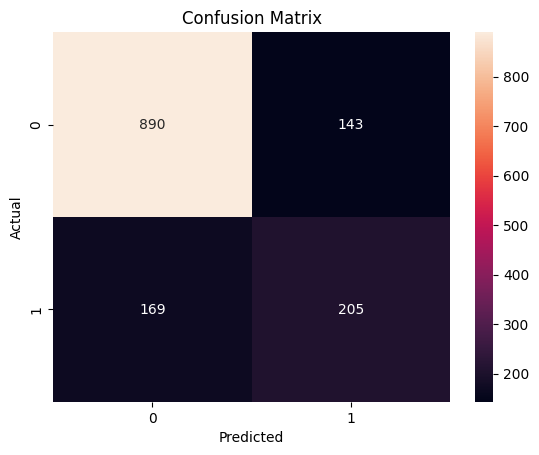

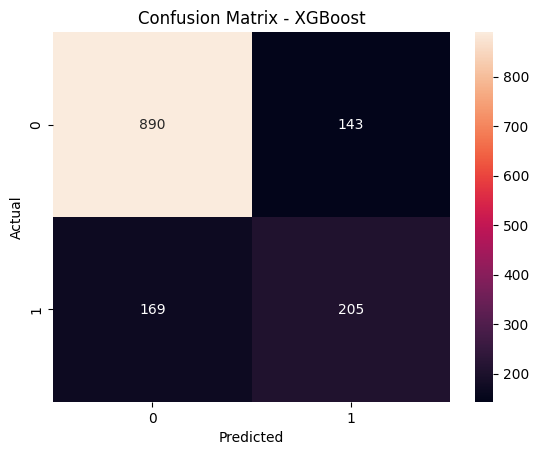

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



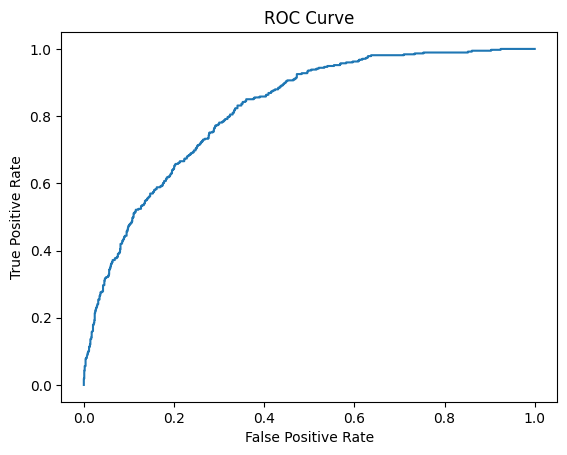

AUC Score: 0.8196701368217795
Recall at threshold 0.3: 0.6978609625668449


In [4]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()
df = df.drop(columns=["customerID"], errors="ignore")
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
import pickle

xgb_model = pickle.load(open("../models/churn_model.pkl", "rb"))
y_pred_xgb = xgb_model.predict(X_test)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))
import numpy as np

threshold = 0.3
y_pred_custom = (y_prob > threshold).astype(int)
from sklearn.metrics import recall_score

print("Recall at threshold 0.3:", recall_score(y_test, y_pred_custom))
def risk_level(prob):
    if prob > 0.7:
        return "High Risk"
    elif prob > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_segments = pd.DataFrame({
    "Actual": y_test,
    "Probability": y_prob
})

risk_segments["Risk"] = risk_segments["Probability"].apply(risk_level)

risk_segments.head()

risk_segments.to_csv("churn_risk_segments.csv", index=False)
xgb_model = pickle.load(open("../models/churn_model.pkl", "rb"))